
## Building a Variational Autoencoder (VAE) and visualize the 2D latent space.

Epoch 1/5 - avg loss: 190.1151
Epoch 2/5 - avg loss: 167.6808
Epoch 3/5 - avg loss: 163.9365
Epoch 4/5 - avg loss: 161.3190
Epoch 5/5 - avg loss: 159.3146


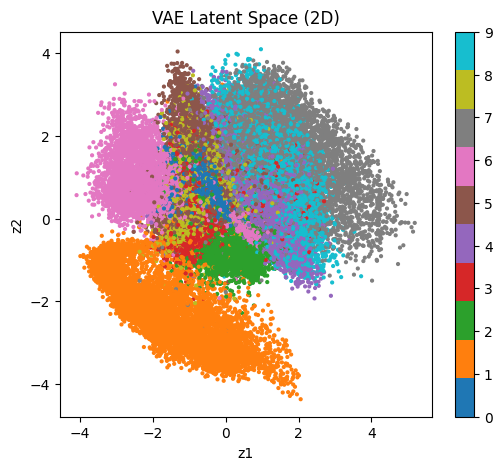

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ---------------------
# DATASET
# ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)

transform = transforms.ToTensor()
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

# ---------------------
# VAE MODEL
# ---------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc = nn.Linear(28 * 28, 400)
        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc(x))
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 400)
        self.out = nn.Linear(400, 28 * 28)

    def forward(self, z):
        h = torch.relu(self.fc(z))
        return torch.sigmoid(self.out(h))


class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl


vae = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# ---------------------
# TRAIN VAE
# ---------------------
epochs = 5
vae.train()
for epoch in range(1, epochs + 1):
    total = 0.0
    for x, _ in train_loader:
        x = x.view(-1, 28 * 28).to(device)
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()

    avg = total / len(train_loader.dataset)
    print(f"Epoch {epoch}/{epochs} - avg loss: {avg:.4f}")

# ---------------------
# LATENT SPACE PLOT
# ---------------------
vae.eval()
latents = []
labels = []
with torch.no_grad():
    for x, y in train_loader:
        x = x.view(-1, 28 * 28).to(device)
        mu, _ = vae.encoder(x)
        latents.append(mu.cpu())
        labels.append(y)

z = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()

plt.figure(figsize=(6, 5))
plt.scatter(z[:, 0], z[:, 1], c=labels, s=4, cmap="tab10")
plt.colorbar()
plt.title("VAE Latent Space (2D)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

## GAN for Image Synthesis (MNIST)

Epoch 1/5 | D: 0.8783 | G: 1.5529
Epoch 2/5 | D: 0.3635 | G: 3.6914
Epoch 3/5 | D: 0.3380 | G: 3.7954
Epoch 4/5 | D: 0.2954 | G: 4.2958
Epoch 5/5 | D: 0.4164 | G: 3.9127


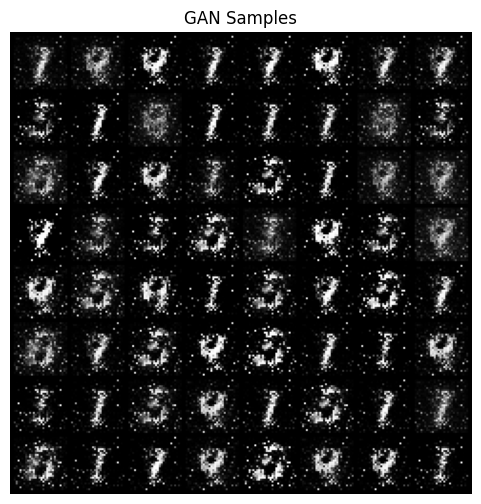

In [2]:
import torch
import torch.nn as nn
from torchvision.utils import make_grid

# ---------------------
# GAN MODEL
# ---------------------
latent_dim = 100

class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)


G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

# ---------------------
# TRAIN GAN
# ---------------------
gan_epochs = 5
G.train()
D.train()
for epoch in range(1, gan_epochs + 1):
    d_running = 0.0
    g_running = 0.0
    for x, _ in train_loader:
        x = x.view(-1, 28 * 28).to(device)
        real = x * 2 - 1  # scale to [-1, 1] for Tanh
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # ---- Train D ----
        z = torch.randn(batch_size, latent_dim, device=device)
        fake = G(z)
        d_real = D(real)
        d_fake = D(fake.detach())
        loss_D = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train G ----
        z = torch.randn(batch_size, latent_dim, device=device)
        fake = G(z)
        g_logits = D(fake)
        loss_G = criterion(g_logits, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        d_running += loss_D.item()
        g_running += loss_G.item()

    print(f"Epoch {epoch}/{gan_epochs} | D: {d_running/len(train_loader):.4f} | G: {g_running/len(train_loader):.4f}")

# ---------------------
# SAMPLE OUTPUT
# ---------------------
G.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim, device=device)
    samples = G(z).view(-1, 1, 28, 28)
    samples = (samples + 1) / 2  # back to [0, 1] for display
    grid = make_grid(samples, nrow=8)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    plt.axis("off")
    plt.title("GAN Samples")
    plt.show()

## GCN on Citation Data (Cora)

In [3]:
%pip -q install torch-geometric

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# ---------------------
# LOAD DATA
# ---------------------
dataset = Planetoid(root="./data", name="Cora")
graph = dataset[0].to(device)

# ---------------------
# GCN MODEL
# ---------------------
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


gcn = GCN(dataset.num_features, 16, dataset.num_classes).to(device)
opt = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)

# ---------------------
# TRAIN + EVAL
# ---------------------
def train_step():
    gcn.train()
    opt.zero_grad()
    out = gcn(graph)
    loss = F.nll_loss(out[graph.train_mask], graph.y[graph.train_mask])
    loss.backward()
    opt.step()
    return loss.item()


def accuracy(mask):
    gcn.eval()
    with torch.no_grad():
        out = gcn(graph)
        pred = out.argmax(dim=1)
        correct = (pred[mask] == graph.y[mask]).sum().item()
        return correct / int(mask.sum())


for epoch in range(1, 201):
    loss = train_step()
    if epoch % 20 == 0:
        train_acc = accuracy(graph.train_mask)
        val_acc = accuracy(graph.val_mask)
        print(f"Epoch {epoch:03d} | loss {loss:.4f} | train {train_acc:.3f} | val {val_acc:.3f}")

test_acc = accuracy(graph.test_mask)
print(f"Test Accuracy: {test_acc:.4f}")

c:\Users\Jitesh\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 020 | loss 0.2868 | train 0.993 | val 0.770
Epoch 040 | loss 0.0523 | train 1.000 | val 0.780
Epoch 060 | loss 0.0394 | train 1.000 | val 0.770
Epoch 080 | loss 0.0432 | train 1.000 | val 0.774
Epoch 100 | loss 0.0410 | train 1.000 | val 0.760
Epoch 120 | loss 0.0331 | train 1.000 | val 0.770
Epoch 140 | loss 0.0301 | train 1.000 | val 0.770
Epoch 160 | loss 0.0277 | train 1.000 | val 0.774
Epoch 180 | loss 0.0234 | train 1.000 | val 0.768
Epoch 200 | loss 0.0252 | train 1.000 | val 0.756
Test Accuracy: 0.7970
